In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

In [29]:
df= pd.read_csv("student_data.csv")
print(df.head())
print(df.shape)

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]
(395, 33)


In [30]:
df.isnull().sum()
df = df.dropna()
df = pd.get_dummies(df, drop_first= True)
df.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


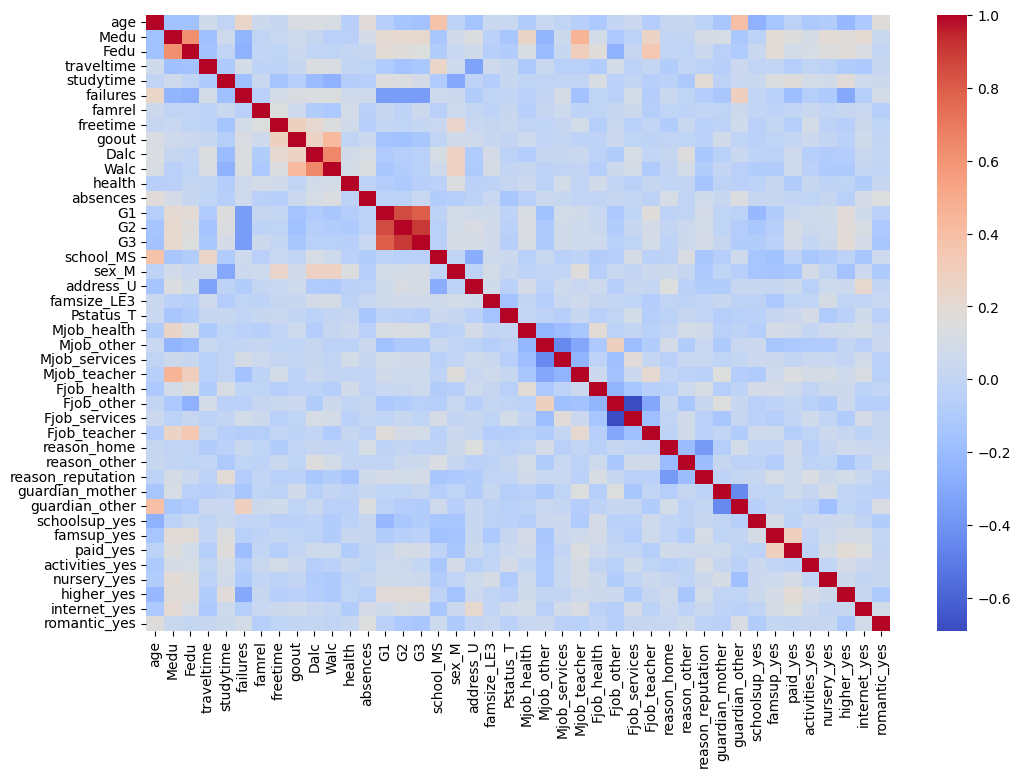

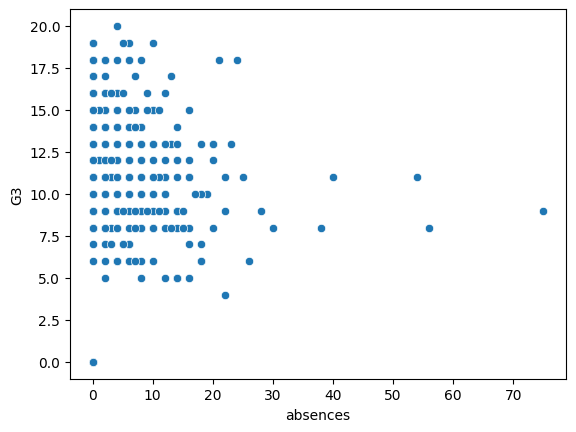

In [31]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()
sns.scatterplot(x=df["absences"], y=df["G3"])
plt.show()

In [32]:
X = df.drop(["G1","G2", "G3"], axis=1)
y = df["G3"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)
print("Linear Regression R2:", r2_score(y_test, pred_lr))
print("MSE:", mean_squared_error(y_test, pred_lr))
print("MAE:", mean_absolute_error(y_test, pred_lr))

Linear Regression R2: 0.14149247411195787
MSE: 17.603737398324714
MAE: 3.39526092580192


In [33]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
print("Random Forest R2:", r2_score(y_test, pred_rf))
print("MSE:", mean_squared_error(y_test, pred_rf))
print("MAE:", mean_absolute_error(y_test, pred_rf))

Random Forest R2: 0.2699904475197701
MSE: 14.968880379746833
MAE: 3.081772151898734


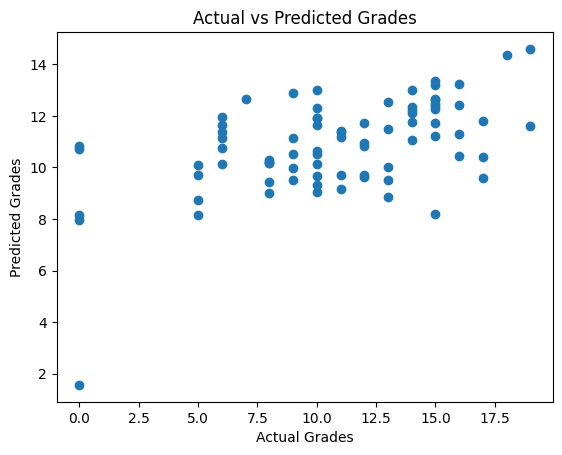

In [34]:
plt.scatter(y_test, pred_rf)
plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")
plt.title("Actual vs Predicted Grades")
plt.show()

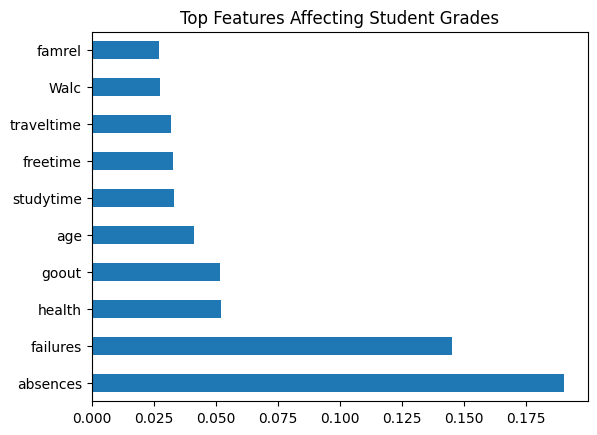

In [35]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.nlargest(10).plot(kind="barh")
plt.title("Top Features Affecting Student Grades")
plt.show()